# Traffic Sign Detection using YOLOv8

## Computer Vision Project

This project compares YOLOv8n and YOLOv8m models for traffic sign detection using the PKDarabi Traffic Sign Dataset.

Developed using Google Colab, Ultralytics YOLOv8, and Python.

## Project Objective

The objective of this project is to compare the performance of two YOLOv8 architectures (YOLOv8n and YOLOv8m) for traffic sign detection using the PKDarabi dataset.

The comparison is based on object detection metrics such as Precision, Recall, F1-Score, and mAP@50.

# 📦 Install Required Libraries

In this step, we install all the required libraries for this project.

- **Ultralytics:** Used to train and run YOLOv8 models.
- **Kaggle API:** Used to download the dataset directly from Kaggle.


In [1]:
!pip install ultralytics kaggle scikit-learn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.4 MB/s eta 0:00:00


# 📚 Import Required Libraries

Import all the Python packages required for data processing, model training, visualization, and image prediction.

In [2]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import glob
from google.colab.patches import cv2_imshow

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# 🔑 Upload Kaggle API Key

Upload the `kaggle.json` file to authenticate your Kaggle account.

In [3]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mohamednasrrr16","key":"cfacbdf5d0467b9b35622ee46158669e"}'}

# ⚙️ Configure Kaggle API

Move the uploaded API key to the correct location and set the required permissions.

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 📥 Download Dataset

Download the traffic sign detection dataset from Kaggle.

In [5]:
!kaggle datasets download -d pkdarabi/cardetection

Dataset URL: https://www.kaggle.com/datasets/pkdarabi/cardetection
License(s): Attribution 4.0 International (CC BY 4.0)
100% 99.8M/99.8M [00:06<00:00, 16.6MB/s]



# 📂 Extract Dataset

Extract the downloaded ZIP file.

In [6]:
!unzip -q cardetection.zip

# 📋 Verify Dataset Structure

Check that the dataset has been extracted correctly.

In [7]:
import os

print("Content Files:")
print(os.listdir('/content'))

print("\nCar Folder:")
print(os.listdir('/content/car'))

Content Files:
['.config', 'cardetection.zip', 'kaggle.json', 'car', 'video.mp4', 'sample_data']

Car Folder:
['README.dataset.txt', 'data.yaml', 'test', 'valid', 'train', 'README.roboflow.txt']


# 📝 Create YOLO Dataset Configuration

Create the `data.yaml` file.

This file tells YOLO:

- Where the training images are.
- Where the validation images are.
- Where the testing images are.
- Number of classes.
- Class names.

In [8]:
data_yaml = """
train: /content/car/train/images
val: /content/car/valid/images
test: /content/car/test/images

nc: 15

names:
  [
    'Green Light',
    'Red Light',
    'Speed Limit 10',
    'Speed Limit 100',
    'Speed Limit 110',
    'Speed Limit 120',
    'Speed Limit 20',
    'Speed Limit 30',
    'Speed Limit 40',
    'Speed Limit 50',
    'Speed Limit 60',
    'Speed Limit 70',
    'Speed Limit 80',
    'Speed Limit 90',
    'Stop'
  ]
"""

with open('/content/data.yaml', 'w') as f:
    f.write(data_yaml)

print("✅ data.yaml created successfully!")

✅ data.yaml created successfully!


# 🚀 Train the YOLOv8m Model

In this step, we train the YOLOv8m model using the custom traffic sign dataset.

### Why YOLOv8m?

- It provides a good balance between detection accuracy and inference speed.
- It has a larger architecture than YOLOv8n, allowing it to learn richer visual features.
- It is suitable for applications where higher detection accuracy is preferred.

In [9]:
# Load the pretrained YOLOv8m model

model_m = YOLO("yolov8m.pt")

# 🏋️ Train the Model

Train YOLOv8m using the traffic sign dataset defined in `data.yaml`.

Training Parameters:

- Epochs: 15
- Image Size: 800 × 800
- Batch Size: 16

In [10]:
model_m.train(
    data="/content/data.yaml",
    epochs=15,
    imgsz=800,
    batch=16,
    name="traffic_sign_detector_m"
)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=traffic_sign_detector_m, nbs=64, nms=False,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7be5e14cefc0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.0

# 💾 Load the Best Trained YOLOv8m Model

After training finishes, YOLO automatically saves the best-performing weights.

We load these weights for future predictions.

In [11]:
best_m = YOLO(
    "/content/runs/detect/traffic_sign_detector_m/weights/best.pt"
)

print("YOLOv8m model loaded successfully!")

YOLOv8m model loaded successfully!


# 📊 Validate the Trained Model

Evaluate the trained model on the validation dataset to obtain performance metrics such as precision, recall, and mAP.

The validation process evaluates the trained model on unseen validation images.

Performance metrics include:

- Precision
- Recall
- mAP50
- mAP50-95

In [12]:
metrics_m = best_m.val()

print(metrics_m)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,848,445 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 820.7±197.9 MB/s, size: 16.0 KB)
val: Scanning /content/car/valid/labels.cache... 801 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 801/801 336.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 51/51 1.5it/s 34.5s
                   all        801        944      0.946      0.928       0.97      0.828
           Green Light         87        122      0.866      0.791      0.879      0.522
             Red Light         74        108      0.841      0.796      0.842      0.507
       Speed Limit 100         52         52      0.944      0.962       0.99      0.894
       Speed Limit 110         17         17      0.833      0.941      0.961      0.865
       Speed Limit 120         60         60     

# 🔍 Run Inference on Test Images

The trained model performs object detection on the testing images and automatically saves the prediction results.

In [13]:
results_m = model_m.predict(
    source="/content/car/test/images",
    save=True,
    conf=0.25
)


image 1/638 /content/car/test/images/000003_jpg.rf.8511b9c219dbf9799a6d58900b15917d.jpg: 800x800 1 Speed Limit 30, 55.9ms
image 2/638 /content/car/test/images/000006_jpg.rf.89610ec419ccfab22f8314026b90ee26.jpg: 800x800 1 Speed Limit 30, 38.6ms
image 3/638 /content/car/test/images/00000_00000_00003_png.rf.d18afc3c9625ffb1974029d3e3762aee.jpg: 800x800 1 Speed Limit 20, 37.2ms
image 4/638 /content/car/test/images/00000_00000_00005_png.rf.ab60a274676963d378f5014e89d9e2b1.jpg: 800x800 1 Speed Limit 20, 37.1ms
image 5/638 /content/car/test/images/00000_00000_00006_png.rf.9d1ea68507aff6973a1dbcdc6f4422a8.jpg: 800x800 1 Speed Limit 20, 33.8ms
image 6/638 /content/car/test/images/00000_00000_00008_png.rf.ff305dcd6e9ceb9188937311a4a1b207.jpg: 800x800 1 Speed Limit 20, 36.5ms
image 7/638 /content/car/test/images/00000_00000_00013_png.rf.9076cbfc7f7811fa22547539a7e7ac02.jpg: 800x800 1 Speed Limit 20, 34.9ms
image 8/638 /content/car/test/images/00000_00000_00017_png.rf.6c2381a6a103a041f23159fbd448

# 📥 Download the Best YOLOv8m Weights

Download the trained model (`best.pt`) to your computer for later use.

In [14]:
from google.colab import files

files.download(
    "/content/runs/detect/traffic_sign_detector_m/weights/best.pt"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 🚀 Train the YOLOv8n Model

In this step, we train the lightweight YOLOv8n model using the same traffic sign dataset.

### Why YOLOv8n?

- It is the smallest model in the YOLOv8 family.
- It offers very fast inference speed.
- It requires fewer computational resources.
- It is suitable for real-time applications and edge devices.

In [15]:
# Load the pretrained YOLOv8n model

model_n = YOLO("yolov8n.pt")

# 🏋️ Train the Model

Train YOLOv8n using the same dataset.

Training Parameters:

- Epochs: 15
- Image Size: 640 × 640
- Batch Size: 16

In [16]:
model_n.train(
    data="/content/data.yaml",
    epochs=15,
    imgsz=640,
    batch=16,
    name="traffic_sign_detector_n"
)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=traffic_sign_detector_n, nbs=64, nms=False,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7be6496ce870>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.0

# 💾 Load the Best Trained YOLOv8n Model

Load the best weights automatically saved during training.

In [17]:
best_n = YOLO(
    "/content/runs/detect/traffic_sign_detector_n/weights/best.pt"
)

print("YOLOv8n model loaded successfully!")

YOLOv8n model loaded successfully!


# 📊 Validate the Trained Model

Evaluate YOLOv8n on the validation dataset to measure its detection performance.

In [18]:
metrics_n = best_n.val()
print(metrics_n)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,008,573 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 760.2±420.4 MB/s, size: 19.7 KB)
val: Scanning /content/car/valid/labels.cache... 801 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 801/801 305.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 51/51 5.5it/s 9.2s
                   all        801        944      0.915      0.895      0.951      0.811
           Green Light         87        122       0.83      0.754      0.838      0.469
             Red Light         74        108      0.791      0.808      0.826      0.491
       Speed Limit 100         52         52      0.929      0.942      0.976      0.883
       Speed Limit 110         17         17      0.864          1      0.983      0.878
       Speed Limit 120         60         60      0.

# 🔍 Run Inference on Test Images

Run object detection using the trained YOLOv8n model.

In [19]:
results_n = best_n.predict(
    source="/content/car/test/images",
    save=True,
    conf=0.25
)


image 1/638 /content/car/test/images/000003_jpg.rf.8511b9c219dbf9799a6d58900b15917d.jpg: 640x640 1 Speed Limit 30, 7.1ms
image 2/638 /content/car/test/images/000006_jpg.rf.89610ec419ccfab22f8314026b90ee26.jpg: 640x640 1 Speed Limit 30, 7.1ms
image 3/638 /content/car/test/images/00000_00000_00003_png.rf.d18afc3c9625ffb1974029d3e3762aee.jpg: 640x640 1 Speed Limit 20, 7.1ms
image 4/638 /content/car/test/images/00000_00000_00005_png.rf.ab60a274676963d378f5014e89d9e2b1.jpg: 640x640 1 Speed Limit 20, 7.1ms
image 5/638 /content/car/test/images/00000_00000_00006_png.rf.9d1ea68507aff6973a1dbcdc6f4422a8.jpg: 640x640 1 Speed Limit 20, 7.1ms
image 6/638 /content/car/test/images/00000_00000_00008_png.rf.ff305dcd6e9ceb9188937311a4a1b207.jpg: 640x640 1 Speed Limit 20, 7.0ms
image 7/638 /content/car/test/images/00000_00000_00013_png.rf.9076cbfc7f7811fa22547539a7e7ac02.jpg: 640x640 1 Speed Limit 20, 9.5ms
image 8/638 /content/car/test/images/00000_00000_00017_png.rf.6c2381a6a103a041f23159fbd44868ed.jp

# 📥 Download the Best YOLOv8n Weights

Download the trained YOLOv8n model for future use.

In [20]:
from google.colab import files

files.download(
    "/content/runs/detect/traffic_sign_detector_n/weights/best.pt"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 🖼️ Visualizing Detection Results

The following section displays sample prediction results generated on the test dataset after model inference.

The images shown below are produced automatically using the best trained YOLOv8 model.

Found 638 predicted images.

/content/runs/detect/predict-2/000946_JPG_jpg.rf.d747fd05b21ff8ac85c05629986ae344.jpg


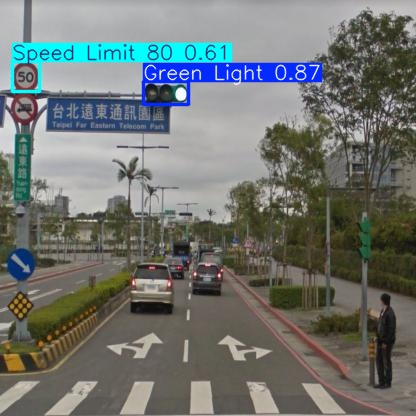

/content/runs/detect/predict-2/road666_png.rf.7d914d9d62e7d0fcc23d5bce18bb5d3c.jpg


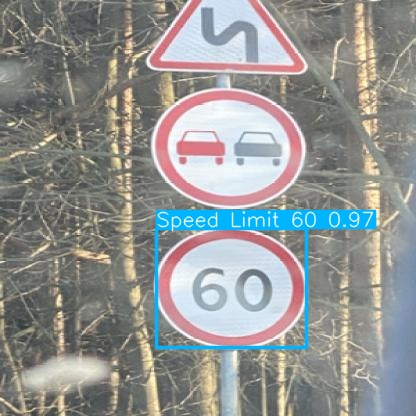

/content/runs/detect/predict-2/road286_png.rf.702db0cc9906e626d838a77a4e79244d.jpg


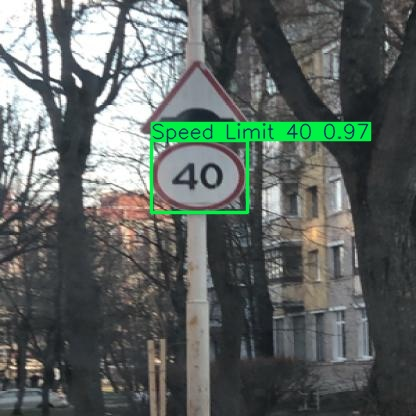

In [21]:
import glob
import cv2
from google.colab.patches import cv2_imshow

def display_latest_prediction():

    prediction_folders = sorted(
        glob.glob("/content/runs/detect/predict*")
    )

    latest_folder = prediction_folders[-1]

    prediction_images = glob.glob(f"{latest_folder}/*.jpg")

    print(f"Found {len(prediction_images)} predicted images.\n")

    for image_path in prediction_images[:3]:
        print(image_path)
        img = cv2.imread(image_path)
        cv2_imshow(img)

display_latest_prediction()

# 📊 Performance Comparison

The following charts compare the performance of the trained YOLOv8m and YOLOv8n models using the evaluation metrics obtained from the validation dataset.

The comparison includes:

- Precision
- Recall
- F1-Score
- mAP@50

These metrics provide a comprehensive evaluation of the object detection performance of each model.

In [4]:
import matplotlib.pyplot as plt

models = ["YOLOv8m", "YOLOv8n"]

precision = [0.946, 0.915]
recall = [0.928, 0.895]

# Approximate F1-score calculated from Precision and Recall
f1_score = [0.937, 0.905]

# mAP@50 is the standard metric for object detection
map50 = [0.970, 0.951]

In [5]:
def plot_metric(metric, title):

    plt.figure(figsize=(6,4))

    plt.bar(models, metric)

    plt.title(title)

    plt.xlabel("Models")

    plt.ylabel(title)

    plt.ylim(0,1)

    plt.show()

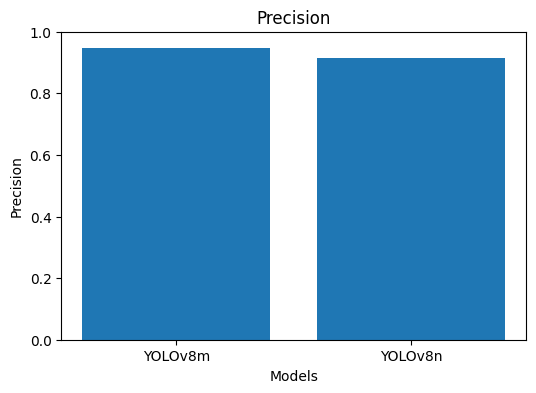

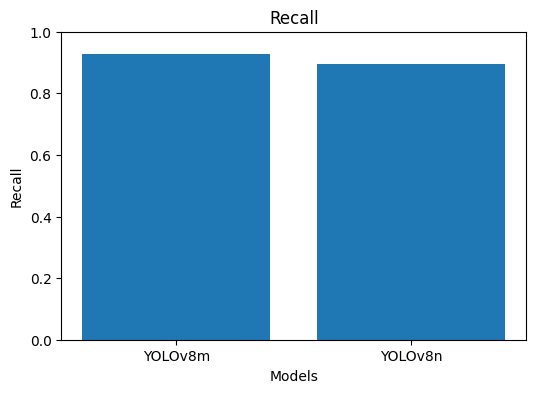

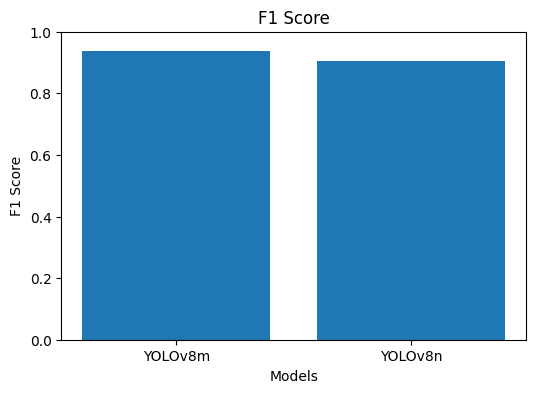

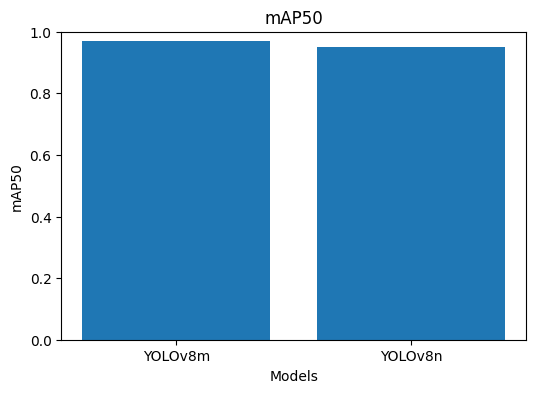

In [6]:
plot_metric(precision, "Precision")
plot_metric(recall, "Recall")
plot_metric(f1_score, "F1 Score")
plot_metric(map50, "mAP50")

# 📌 Results Summary

The experimental results indicate that both YOLOv8 models successfully detected traffic signs.

### Key Findings

- YOLOv8m achieved better overall detection performance.
- YOLOv8n required fewer computational resources and provided faster inference.
- The comparison demonstrates the trade-off between model accuracy and inference speed.

# 🏁 Conclusion

This project presented a comparative study of YOLOv8m and YOLOv8n for traffic sign detection using the PKDarabi dataset.

Both models achieved satisfactory detection results. However, YOLOv8m provided higher detection accuracy, while YOLOv8n offered faster inference and lower computational cost.

The project demonstrates how different YOLOv8 architectures can be selected depending on the deployment requirements.

# 📚 References

- Ultralytics YOLOv8 Documentation
- PKDarabi Traffic Sign Detection Dataset (Kaggle)
- OpenCV Documentation
- Matplotlib Documentation
- Google Colab Documentation

In [25]:
print("🎉 Traffic Sign Detection Project Completed Successfully!")

🎉 Traffic Sign Detection Project Completed Successfully!
